In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("Data/Gender_Data.csv")
df2 = pd.read_csv("Data/data.csv")
data = pd.concat([df1, df2], axis=0)

In [3]:
data.sample(10)

,Name,Gender,Count,Probability
49463,Lovene,F,62.0,1.696780e-07
2168,Ahathiyan,0,NaN,NaN
35024,Eaellisaipaamagal,1,NaN,NaN
52655,Nathally,F,52.0,1.423110e-07
86392,Jhalin,M,10.0,2.736740e-08
1085,Jana,F,46983.0,1.285800e-04
73777,Lumas,M,17.0,4.652460e-08
137938,Glendyn,M,1.0,2.736740e-09
8235,Courtnee,F,1691.0,4.627830e-06
50733,Almo,M,58.0,1.587310e-07


In [4]:
data.drop(columns=['Count','Probability'], inplace=True)
data.sample(10)

,Name,Gender
109541,Shalimar,M
59541,Aroosh,F
7311,Goplilal,0
8503,Illamai,0
90745,Aliezah,F
9559,Jeevakan,0
93173,Raylani,F
90581,Ware,M
59670,Keydra,F
84405,Jamiles,F


In [5]:
data['Gender'].value_counts()

,count
Gender,
F,89749
M,57520
0,29014
1,24968


In [6]:
data['Gender'] = data['Gender'].replace({
    0: 'Male',
    1: 'Female',
    'M': 'Male',
    'F': 'Female'
})

data.sample(10)

,Name,Gender
132,Aalliyan,Male
119827,Dur-E-Shehwar,Female
31045,Teliyah,Female
35679,Adebayo,Male
4068,Bhuumka,Male
87944,Mykila,Female
26610,Leovardo,Male
124129,Kokopelli,Female
72988,Kaeliegh,Female
130262,Sharinal,Female


In [7]:
data['Gender'].value_counts()

,count
Gender,
Female,114717
Male,86534


In [8]:
data.isnull().sum()

,0
Name,0
Gender,0


In [9]:
len(data['Name'].unique()) == len(data)

False

In [10]:
len(data) - len(data['Name'].unique())

21053

In [11]:
# Identify names with both 'M' and 'F' genders
ambiguous_names = (
    data.groupby('Name')['Gender']
    .nunique()
    .reset_index()
)

ambiguous_names = ambiguous_names[
    ambiguous_names['Gender'] > 1
]['Name']


data.loc[data['Name'].isin(ambiguous_names), 'Gender'] = 'Neutral'

data = data.drop_duplicates(['Name','Gender'])

In [12]:
data['Gender'].unique()

array(['Male', 'Neutral', 'Female'], dtype=object)

In [13]:
data.head()

,Name,Gender
0,Aaban,Male
1,Aabharan,Male
2,Aabhas,Male
3,Aabhat,Male
4,Aabheer,Male


In [14]:
duplicates = data[data.duplicated(subset=['Name', 'Gender'], keep=False)]

print(duplicates)

Empty DataFrame
Columns: [Name, Gender]
Index: []


In [15]:
# Just making this easier to view sorting
data.sort_values(by = "Name", inplace = True)
data.head()

,Name,Gender
112246,A,Neutral
115618,A'Aff,Female
133954,A'Aron,Male
115619,A'Dele,Female
115620,A'Isha,Female


In [16]:
data = data[data['Gender'] != 'Neutral']
data.head()

,Name,Gender
115618,A'Aff,Female
133954,A'Aron,Male
115619,A'Dele,Female
115620,A'Isha,Female
115621,A'Ishah,Female


In [17]:
data['Gender'].value_counts()

,count
Gender,
Female,97206
Male,69100


In [18]:
# What unique characters in the names?
characters_unique = set()
cols = ['Name']
for col in cols:
    for value in data[col]:
        for letter in value:
            if letter not in string.ascii_lowercase and letter not in string.ascii_uppercase:
                characters_unique.add(letter)

characters_unique

{'"',
 '&',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '5',
 '7',
 '8',
 '9',
 ';',
 '?',
 '@',
 '[',
 '¡',
 'à',
 'ö',
 'œ',
 '…'}

In [19]:
import re
import unicodedata
def clean_name(name):
    # Convert to string
    name = str(name)

    # Normalize unicode (é → e, ö → o)
    name = unicodedata.normalize('NFKD', name)

    # Encode to ASCII (ignore non-ascii parts)
    name = name.encode('ascii', 'ignore').decode('utf-8')

    # Keep only alphabets
    name = re.sub(r'[^a-zA-Z]', '', name)

    return name.lower()

In [20]:
data['Name'] = data['Name'].apply(clean_name)
data.head()

,Name,Gender
115618,aaff,Female
133954,aaron,Male
115619,adele,Female
115620,aisha,Female
115621,aishah,Female


In [21]:
data.isnull().sum()

,0
Name,0
Gender,0


In [22]:
import string

characters_unique = set()

cols = ['Name']

for col in cols:
    for value in data[col]:
        value = str(value)  # handle NaN or non-string
        for letter in value:
            if letter not in string.ascii_letters:
                characters_unique.add(letter)

characters_unique

set()

In [23]:
min_len = data['Name'].astype(str).apply(len).min()
max_len = data['Name'].astype(str).apply(len).max()

print("Minimum Name Length:", min_len)
print("Maximum Name Length:", max_len)

Minimum Name Length: 1
Maximum Name Length: 24


In [24]:
data['name_len'] = data['Name'].astype(str).str.len()

print(data['name_len'].describe())

count    166306.000000
mean          7.292984
std           1.961040
min           1.000000
25%           6.000000
50%           7.000000
75%           8.000000
max          24.000000
Name: name_len, dtype: float64


In [25]:
min_len = data['Name'].astype(str).apply(len).min()
max_len = data['Name'].astype(str).apply(len).max()

print("Minimum Name Length:", min_len)
print("Maximum Name Length:", max_len)

Minimum Name Length: 1
Maximum Name Length: 24


In [26]:
data = data[data['Name'].notna()]
data['Name'] = data['Name'].str.strip()
data = data[
    (data['Name'].str.len() >= 2) &
    (data['Name'].str.len() < 20)
]

In [27]:
print(data['Gender'].value_counts())

Gender
Female    97191
Male      69067
Name: count, dtype: int64


In [28]:
data = data.drop_duplicates().reset_index(drop=True)

In [29]:
data.isnull().sum()

,0
Name,0
Gender,0
name_len,0


In [30]:
data.duplicated(subset=['Name', 'Gender']).sum()

np.int64(0)

In [31]:
data['name_len'].skew()

np.float64(0.918155705404755)

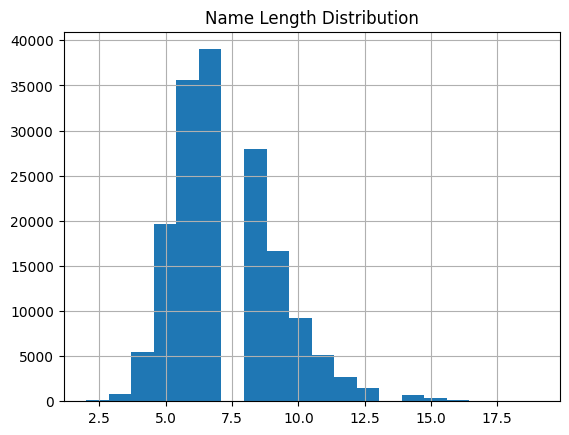

In [32]:
import matplotlib.pyplot as plt

data['name_len'].hist(bins=20)
plt.title("Name Length Distribution")
plt.show()

In [33]:
data['Gender'].value_counts()

,count
Gender,
Female,96192
Male,68828


In [34]:
gender_percent = data['Gender'].value_counts(normalize=True) * 100
print(gender_percent)

Gender
Female    58.291116
Male      41.708884
Name: proportion, dtype: float64


In [35]:
data.drop(columns=['name_len'], inplace=True)
data.head()

,Name,Gender
0,aaff,Female
1,aaron,Male
2,adele,Female
3,aisha,Female
4,aishah,Female


In [36]:
# Text Normalization
data['Name'] = data['Name'].astype(str).str.strip().str.lower()

In [37]:
# Features and target
X = data['Name']
y = data['Gender']

In [38]:
# Character TF-IDF
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
)
X=vectorizer.fit_transform(data['Name'])

In [39]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

In [40]:
model = LogisticRegression(
    C=3,
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced'
)
model.fit(x_train, y_train)

LogisticRegression(C=3, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

In [41]:
y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)
# Results
print("Test Data Accuracy:", accuracy_score(y_test, y_pred))
print("Train Data Accuracy: ", accuracy_score(y_train, y_train_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Data Accuracy: 0.8909829111622833
Train Data Accuracy:  0.9461656162889347

Classification Report:

              precision    recall  f1-score   support

      Female       0.92      0.89      0.91     19238
        Male       0.86      0.89      0.87     13766

    accuracy                           0.89     33004
   macro avg       0.89      0.89      0.89     33004
weighted avg       0.89      0.89      0.89     33004



In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[17167  2071]
 [ 1527 12239]]


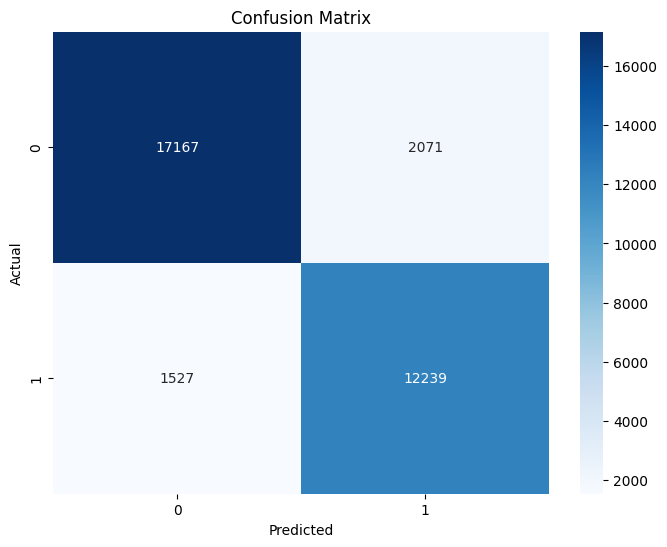

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [44]:
import joblib
import os

# create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# save files
joblib.dump(vectorizer, "models/vectorizer.pkl")
joblib.dump(model, "models/gender_model.pkl")

['models/gender_model.pkl']

In [45]:
# Load trained model and vectorizer
vectorizer = joblib.load("models/vectorizer.pkl")
model = joblib.load("models/gender_model.pkl")


# Load datasets
data = pd.read_csv("Data/test_names.csv")


# Prediction
X = vectorizer.transform(data["Name"])

predicted_gender = model.predict(X)


# Result table
result = pd.DataFrame({
    "Name": data["Name"],
    "Actual Gender": data["Gender"],
    "Predicted Gender": predicted_gender
})

print(result)


# Accuracy
accuracy = accuracy_score(
    data["Gender"],
    predicted_gender
)


print("\nTotal Gender Prediction Accuracy:",
      round(accuracy * 100, 2),
      "%")

          Name Actual Gender Predicted Gender
0         John          Male             Male
1         Mary        Female           Female
2      Michael          Male             Male
3     Jennifer        Female           Female
4        David          Male             Male
...        ...           ...              ...
9995     Salih          Male             Male
9996    Tovino          Male             Male
9997    Thomas          Male             Male
9998    Ansaad          Male             Male
9999      Adil          Male             Male

[10000 rows x 3 columns]

Total Gender Prediction Accuracy: 89.47 %


In [46]:
# Load model
vectorizer = joblib.load("models/vectorizer.pkl")
model = joblib.load("models/gender_model.pkl")


names = [
    "Bhavya Gupta",
    "Ansh Tyagi",
    "Kumar Ambuj"
]


for name in names:

    # Transform
    X = vectorizer.transform([name])


    # Prediction
    prediction = model.predict(X)[0]


    # Probability
    probabilities = model.predict_proba(X)[0]

    classes = model.classes_


    all_probabilities = {
        cls: round(float(prob), 2)
        for cls, prob in zip(classes, probabilities)
    }


    max_probability = max(probabilities)


    if max_probability >= 0.85:
        confidence = "high"

    elif max_probability >= 0.65:
        confidence = "medium"

    else:
        confidence = "low"


    result = {
        "input": name,
        "predicted_gender": prediction,
        "confidence": confidence,
        "probability": round(float(max_probability), 2),
        "all_probabilities": all_probabilities
    }


    print(result)
    print()

{'input': 'Bhavya Gupta', 'predicted_gender': 'Male', 'confidence': 'low', 'probability': 0.52, 'all_probabilities': {'Female': 0.48, 'Male': 0.52}}

{'input': 'Ansh Tyagi', 'predicted_gender': 'Male', 'confidence': 'high', 'probability': 0.94, 'all_probabilities': {'Female': 0.06, 'Male': 0.94}}

{'input': 'Kumar Ambuj', 'predicted_gender': 'Male', 'confidence': 'high', 'probability': 0.97, 'all_probabilities': {'Female': 0.03, 'Male': 0.97}}

